<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-12</br>
</div>

</br>

In [61]:
# TODO 0: 실습을 위해 아래 패키지를 import 해주세요.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine

wine_dataset = load_wine()
wine_dataframe = pd.DataFrame(wine_dataset.data, columns=wine_dataset.feature_names)
wine_dataframe["quality"] = wine_dataset.target

# 피처와 타겟 분리
features = wine_dataframe.drop("quality", axis=1).values
target = wine_dataframe["quality"].values

# 데이터 분할
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

# 스케일링
standard_scaler = StandardScaler()
features_all_scaled = standard_scaler.fit_transform(features)
features_train_scaled = standard_scaler.fit_transform(features_train)
features_test_scaled = standard_scaler.transform(features_test)

# 모델 학습
logistic_model = LogisticRegression(max_iter=5000, random_state=42)
logistic_model.fit(features_train_scaled, target_train)
target_predicted = logistic_model.predict(features_test_scaled)

print("전처리 파이프라인 완료!")
print(f"학습 데이터: {features_train_scaled.shape}, 테스트 데이터: {features_test_scaled.shape}")

전처리 파이프라인 완료!
학습 데이터: (142, 13), 테스트 데이터: (36, 13)


</br>

# 학습 내용
>이번 장에서는 <strong>모델 검증 및 해석(Model Validation & Interpretation)</strong>에 대해 학습합니다.</br></br>
>교차 검증, ROC 곡선, 차원 축소, 군집 분석, 혼동 행렬을 활용한 모델 평가를 학습해봅시다.

</br>

# 교차 검증 (Cross-Validation)
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">데이터를 여러 번 나누어</mark> 모델의 일반화 성능을 안정적으로 평가하는 기법입니다.

In [62]:
# TODO 1: cross_val_score를 import 해봅시다.

from sklearn.model_selection import cross_val_score

In [63]:
# TODO 2: 5-Fold 교차검증(cv=5, scoring="accuracy")을 수행해봅시다.

cross_validation_scores = cross_val_score(logistic_model, features, target, cv=5, scoring="accuracy")
print(f"각 Fold 정확도: {cross_validation_scores.round(4)}")

각 Fold 정확도: [0.9722 0.9167 0.9167 1.     1.    ]


In [64]:
# TODO 3: 교차검증 평균 정확도와 표준편차를 출력해봅시다.

mean_accuracy = cross_validation_scores.mean()
std_accuracy = cross_validation_scores.std()
print(f"평균 정확도: {mean_accuracy:.4f} (±{std_accuracy:.4f})")

평균 정확도: 0.9611 (±0.0377)


💡cv 파라미터
> `cv=5`는 5-Fold 교차 검증으로, 데이터를 5등분하여 각각을 테스트로 사용합니다.</br>
> 작은 데이터셋에서 특히 유용합니다.

</br>

# 혼동 행렬 (Confusion Matrix)
> 분류 모델의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">예측 결과를 실제 값과 비교</mark>하는 표입니다.

In [65]:
# TODO 4: confusion_matrix, classification_report를 import 해봅시다.

from sklearn.metrics import confusion_matrix, classification_report

In [66]:
# TODO 5: 혼동 행렬을 구해봅시다.

confusion_matrix_result = confusion_matrix(target_test, target_predicted)
print("혼동 행렬:")
print(confusion_matrix_result)

혼동 행렬:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


In [67]:
# TODO 6: 분류 보고서를 출력해봅시다.

classification_report_result = classification_report(target_test, target_predicted)
print("분류 보고서:")
print(classification_report_result)

분류 보고서:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



</br>

## 주요 평가 지표

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">지표</th>
      <th style="text-align:center">공식</th>
      <th style="text-align:center">의미</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">정확도(Accuracy)</td><td style="text-align:center">$\frac{TP+TN}{전체}$</td><td style="text-align:center">전체 정답 비율</td></tr>
    <tr><td style="text-align:center">정밀도(Precision)</td><td style="text-align:center">$\frac{TP}{TP+FP}$</td><td style="text-align:center">양성 예측 중 실제 양성</td></tr>
    <tr><td style="text-align:center">재현율(Recall)</td><td style="text-align:center">$\frac{TP}{TP+FN}$</td><td style="text-align:center">실제 양성 중 탐지 비율</td></tr>
    <tr><td style="text-align:center">F1-Score</td><td style="text-align:center">$2 \times \frac{P \times R}{P + R}$</td><td style="text-align:center">정밀도·재현율 조화 평균</td></tr>
  </tbody>
</table>

💡불균형 데이터에서의 정확도
> 클래스 불균형이 심한 경우 정확도만으로는 성능을 판단할 수 없습니다.</br>
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">F1-Score</mark>나 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">AUROC</mark>를 함께 확인하세요.

</br>

# ROC 곡선 (ROC Curve)
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">FPR(위양성률) 대비 TPR(진양성률)</mark>을 시각화하여 분류 모델의 전체 성능을 평가합니다.

In [68]:
# TODO 7: roc_curve, roc_auc_score, label_binarize를 import 해봅시다.

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

In [69]:
# TODO 8: 다중 클래스 ROC를 위해 라벨을 이진화하고, 예측 확률을 구해봅시다.

target_classes = np.unique(target)
target_test_binarized = label_binarize(target_test, classes=target_classes)
prediction_probabilities = logistic_model.predict_proba(features_test_scaled)

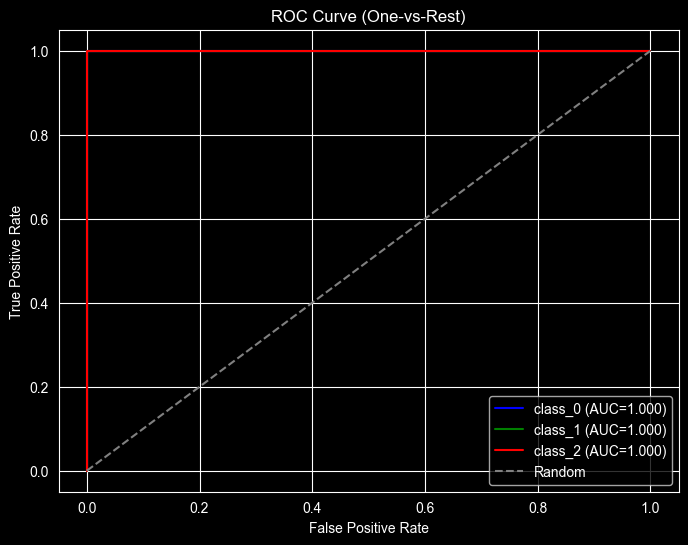

In [70]:
# TODO 9: 각 클래스별 ROC 곡선을 그리고 AUC 값을 확인해봅시다.

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["blue", "green", "red"]
for i, (color, name) in enumerate(zip(colors, wine_dataset.target_names)):
    false_positive_rate, true_positive_rate, _ = roc_curve(target_test_binarized[:, i], prediction_probabilities[:, i])
    auc_score = roc_auc_score(target_test_binarized[:, i], prediction_probabilities[:, i])
    ax.plot(false_positive_rate, true_positive_rate, color=color, label=f"{name} (AUC={auc_score:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (One-vs-Rest)")
ax.legend()
plt.show()

💡ROC 곡선의 장점
> 임계값(threshold)에 독립적으로 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">모델 자체의 분류 능력</mark>을 평가합니다.</br>
> 클래스 불균형에도 안정적이어서 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">불균형 데이터</mark>에서 정확도보다 신뢰할 수 있습니다.

</br>

In [71]:
# TODO 10: PCA를 import 해봅시다.

from sklearn.decomposition import PCA

In [72]:
# TODO 11: PCA로 features_all_scaled를 2차원으로 축소해봅시다.

pca_model = PCA(n_components=2)
features_pca = pca_model.fit_transform(features_all_scaled)

print(f"축소 전: {features_all_scaled.shape} → 축소 후: {features_pca.shape}")
print(f"  (178개 샘플, 13개 특성) → (178개 샘플, 2개 주성분)")
print(f"\n설명된 분산 비율: {pca_model.explained_variance_ratio_.round(4)}")
print(f"총 설명 분산: {pca_model.explained_variance_ratio_.sum():.4f}")

축소 전: (178, 13) → 축소 후: (178, 2)
  (178개 샘플, 13개 특성) → (178개 샘플, 2개 주성분)

설명된 분산 비율: [0.362  0.1921]
총 설명 분산: 0.5541


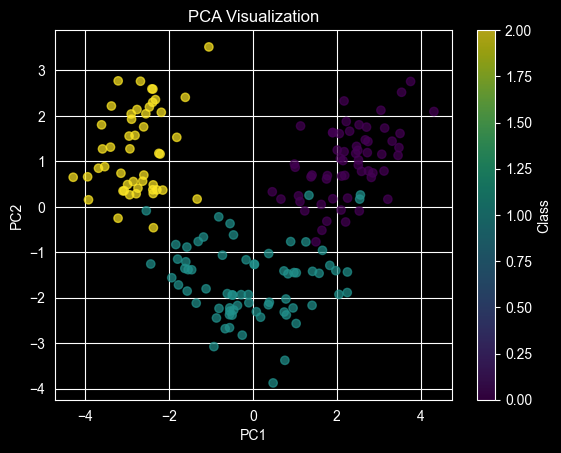

In [73]:
# TODO 12: PCA 결과를 산점도로 시각화해봅시다.

scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], c=target, cmap="viridis", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.colorbar(scatter, label="Class")
plt.show()

💡PCA 활용
> 시각화(2D/3D), 노이즈 제거, 연산 속도 향상에 사용됩니다.</br>
> `explained_variance_ratio_`로 각 주성분이 보존하는 정보량을 확인합니다.

</br>

In [77]:
# TODO 13: KMeans를 import 해봅시다.

from sklearn.cluster import KMeans

In [78]:
# TODO 14: KMeans(n_clusters=3, random_state=42, n_init=10)로 features_all_scaled를 클러스터링해봅시다.

kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(features_all_scaled)

print(f"클러스터 레이블 (처음 10개): {cluster_labels[:10]}")
print(f"클러스터별 크기: {[sum(cluster_labels == i) for i in range(3)]}")

클러스터 레이블 (처음 10개): [2 2 2 2 2 2 2 2 2 2]
클러스터별 크기: [np.int64(65), np.int64(51), np.int64(62)]


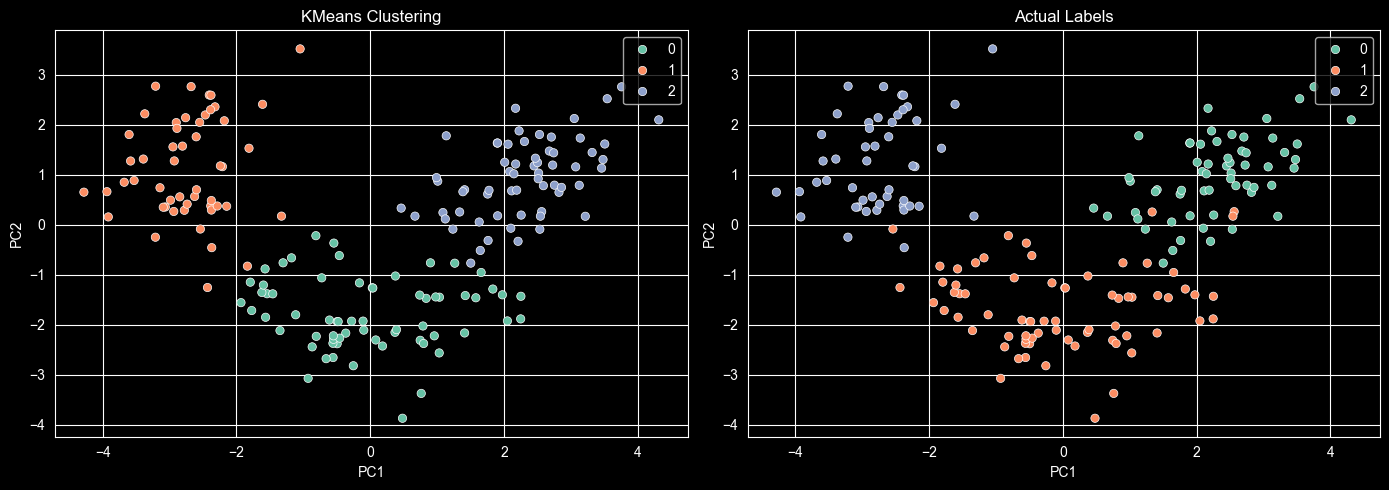

In [79]:
# TODO 15: KMeans 결과와 실제 라벨을 나란히 시각화해봅시다.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=features_pca[:, 0], y=features_pca[:, 1], hue=cluster_labels, palette="Set2", ax=axes[0])
axes[0].set_title("KMeans Clustering")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sns.scatterplot(x=features_pca[:, 0], y=features_pca[:, 1], hue=target, palette="Set2", ax=axes[1])
axes[1].set_title("Actual Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()